# Chapter 3 – Classification (Heart Disease dataset)

Hands-On Machine Learning (Géron, 2nd ed.), Chapter 3, applied to the UCI Heart Disease data (`heart.csv`, 1025 rows, binary `target`).

In [1]:
import pandas as pd
df=pd.read_csv("heart.csv")

In [2]:
df.shape

(1025, 14)

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df[["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]].describe()

,age,trestbps,chol,thalach,oldpeak,ca
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512,0.754146
std,9.072290,17.516718,51.59251,23.005724,1.175053,1.030798
min,29.000000,94.000000,126.00000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000,0.000000
75%,61.000000,140.000000,275.00000,166.000000,1.800000,1.000000
max,77.000000,200.000000,564.00000,202.000000,6.200000,4.000000


In [7]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [8]:
df["target"].value_counts(normalize=True)

target
1    0.513171
0    0.486829
Name: proportion, dtype: float64

In [9]:
df.duplicated().sum()

np.int64(723)

In [10]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [11]:
df.index

RangeIndex(start=0, stop=1025, step=1)

In [12]:
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
60,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
64,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
118,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
668,29,1,1,130,204,0,0,202,0,0.0,2,0,2,1
12,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
779,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
143,34,1,3,118,182,0,0,174,0,0.0,2,0,2,1
201,34,1,3,118,182,0,0,174,0,0.0,2,0,2,1
572,34,1,3,118,182,0,0,174,0,0.0,2,0,2,1


In [13]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [14]:
df.drop_duplicates().shape

(302, 14)

In [15]:
df.drop_duplicates()["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

In [16]:
df_clean = df.dropna()  # or df.copy(), depending on your cleaning step
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(
    X, y,test_size=0.2, random_state=42,stratify=y
)

In [18]:
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline.score(X_test, y_test)

0.5121951219512195

In [19]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [20]:
y_pred = log_reg.predict(X_test)

In [21]:
y_prob = log_reg.predict_proba(X_test)

y_prob[:5]

array([[0.9871916 , 0.0128084 ],
       [0.61827342, 0.38172658],
       [0.99100164, 0.00899836],
       [0.27271924, 0.72728076],
       [0.70715154, 0.29284846]])

In [22]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8146341463414634

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
from sklearn.pipeline import Pipeline

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('logistic', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn=knn.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_knn)

0.8634146341463415

In [28]:
for k in [1, 3, 5, 7, 9, 11, 15, 20]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_knn = knn.predict(X_test_scaled)

    print(k, accuracy_score(y_test, y_pred_knn))

1 1.0
3 0.9463414634146341
5 0.8634146341463415
7 0.8439024390243902
9 0.8536585365853658
11 0.8585365853658536
15 0.848780487804878
20 0.8439024390243902


In [29]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

lda.fit(X_train_scaled, y_train)

y_pred_lda = lda.predict(X_test_scaled)

accuracy_score(y_test, y_pred_lda)

0.8048780487804879

In [30]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train_scaled, y_train)

y_pred_qda = qda.predict(X_test_scaled)

accuracy_score(y_test, y_pred_qda)

0.8292682926829268

In [31]:
from sklearn.svm import SVC

svm = SVC(kernel="linear")

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

accuracy_score(y_test, y_pred_svm)

0.8146341463414634

In [32]:
from sklearn.svm import SVC

svm_rbf = SVC(kernel="rbf")

svm_rbf.fit(X_train_scaled, y_train)

y_pred_svm = svm_rbf.predict(X_test_scaled)

accuracy_score(y_test, y_pred_svm)

0.926829268292683

In [33]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

accuracy_score(y_test, y_pred_tree)

0.9853658536585366

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_score(y_test, y_pred_rf)

1.0

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

print(cm)

[[100   0]
 [  0 105]]


In [36]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print(scores)
print("Mean:", scores.mean())

[0.95121951 0.98780488 0.98780488 0.98170732 1.        ]
Mean: 0.9817073170731707


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [38]:
models = {
    "Logistic Regression": log_reg_pipeline,
    "KNN": knn,
    "LDA": lda,
    "QDA": qda,
    "SVM": svm_rbf,
    "Decision Tree": tree,
    "Random Forest": rf
}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    print(name, ":", round(scores.mean(), 4))

Logistic Regression : 0.8439
KNN : 0.7085


LDA : 0.8366
QDA : 0.8415


SVM : 0.7012
Decision Tree : 0.9866


Random Forest : 0.9817


In [39]:
X = df_clean.drop("target", axis=1)
y = df_clean["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

Precision: 1.0
Recall: 1.0


In [41]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred_rf)

1.0

In [42]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob_rf)

print("AUC:", auc)

AUC: 1.0


In [43]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    print(
        threshold,
        "Precision:", precision_score(y_test, y_pred_threshold),
        "Recall:", recall_score(y_test, y_pred_threshold)
    )

0.3 Precision: 1.0 Recall: 1.0
0.4 Precision: 1.0 Recall: 1.0
0.5 Precision: 1.0 Recall: 1.0
0.6 Precision: 1.0 Recall: 1.0
0.7 Precision: 1.0 Recall: 1.0


## Fixing data leakage from duplicate rows

723 of the 1025 rows are exact duplicates, so the same patient can land in both the train and test sets. That is why Random Forest and the Decision Tree score 100% above. Below, everything is re-run on the 302 unique rows.

In [44]:
df_unique = df.drop_duplicates().reset_index(drop=True)
X = df_unique.drop("target", axis=1)
y = df_unique["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(241, 13) (61, 13)


In [45]:
from sklearn.pipeline import make_pipeline

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "KNN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "SVM (rbf)": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=42)),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, m in models.items():
    scores = cross_val_score(m, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name:20s}: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression : 0.8216 ± 0.0210


KNN (k=5)           : 0.8093 ± 0.0396


LDA                 : 0.8215 ± 0.0172
QDA                 : 0.7759 ± 0.0623


SVM (rbf)           : 0.8132 ± 0.0327


Decision Tree       : 0.7263 ± 0.0414


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedC

Random Forest       : 0.8132 ± 0.0300


## Confusion matrix with `cross_val_predict`

Predictions for every training row come from a model that never saw that row, so the test set stays untouched.

[[ 81  29]
 [ 14 117]]
Precision: 0.8013698630136986
Recall:    0.8931297709923665
F1:        0.8447653429602888


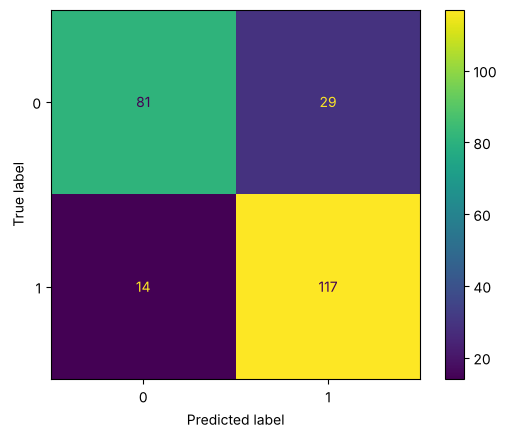

In [46]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay

clf = models["Logistic Regression"]
y_train_pred = cross_val_predict(clf, X_train, y_train, cv=5)

print(confusion_matrix(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:   ", recall_score(y_train, y_train_pred))
print("F1:       ", f1_score(y_train, y_train_pred))

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)

## Precision/Recall trade-off

For a disease screen, missing a sick patient (false negative) is worse than a false alarm, so pick the threshold that gives at least 90% recall.

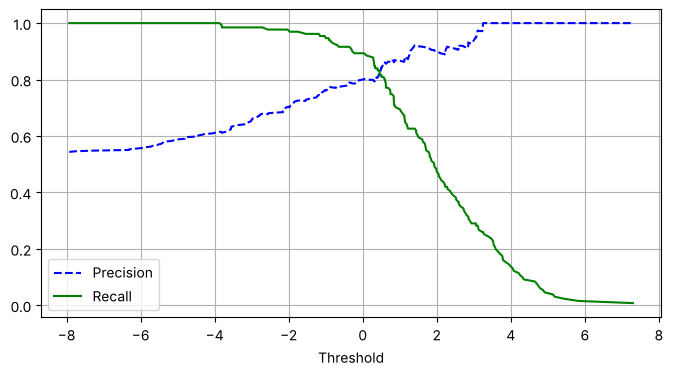

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

y_scores = cross_val_predict(clf, X_train, y_train, cv=5, method="decision_function")
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.grid(True)
plt.show()

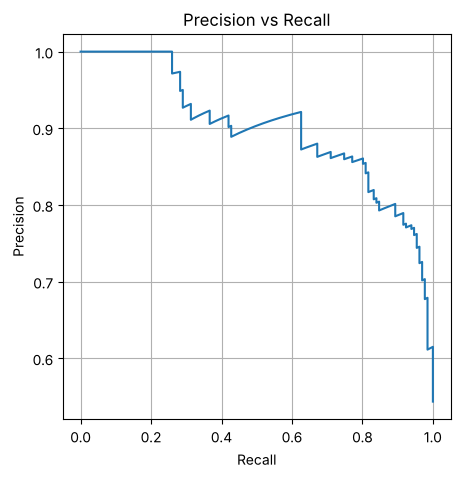

In [48]:
plt.figure(figsize=(5, 5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall")
plt.grid(True)
plt.show()

In [49]:
idx = np.argmax(recalls[:-1] < 0.90) - 1
threshold_90_recall = thresholds[idx]
print("Threshold:", threshold_90_recall)

y_train_pred_90 = (y_scores >= threshold_90_recall)
print("Precision:", precision_score(y_train, y_train_pred_90))
print("Recall:   ", recall_score(y_train, y_train_pred_90))

Threshold: -0.2858222565127012
Precision: 0.7866666666666666
Recall:    0.9007633587786259


## ROC curve: Logistic Regression vs Random Forest

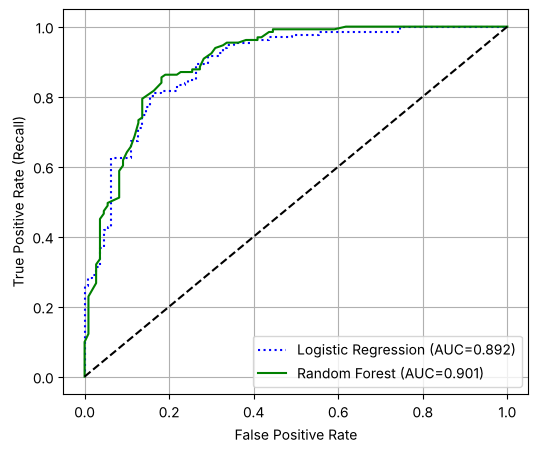

In [50]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_train, y_scores)

y_probas_rf = cross_val_predict(models["Random Forest"], X_train, y_train, cv=5, method="predict_proba")
y_scores_rf = y_probas_rf[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_train, y_scores_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, "b:", label=f"Logistic Regression (AUC={roc_auc_score(y_train, y_scores):.3f})")
plt.plot(fpr_rf, tpr_rf, "g-", label=f"Random Forest (AUC={roc_auc_score(y_train, y_scores_rf):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.grid(True)
plt.show()

## Final evaluation on the test set

In [51]:
from sklearn.metrics import classification_report

final_model = models["Logistic Regression"]
final_model.fit(X_train, y_train)

test_scores = final_model.decision_function(X_test)
y_test_pred = (test_scores >= threshold_90_recall).astype(int)

print(classification_report(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, test_scores))

              precision    recall  f1-score   support

           0       0.79      0.68      0.73        28
           1       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61

ROC AUC: 0.8712121212121212


## Multiclass classification

Predict chest-pain type `cp` (4 classes). SVC uses One-vs-One internally; `OneVsRestClassifier` forces One-vs-Rest.

In [52]:
from sklearn.multiclass import OneVsRestClassifier

X_mc = df_unique.drop(["cp", "target"], axis=1)
y_mc = df_unique["cp"]
X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc
)

ovo = make_pipeline(StandardScaler(), SVC(random_state=42))
ovr = make_pipeline(StandardScaler(), OneVsRestClassifier(SVC(random_state=42)))
sgd_mc = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

for name, m in [("SVC (OvO)", ovo), ("SVC (OvR)", ovr), ("Softmax LogReg", sgd_mc)]:
    print(f"{name:15s}:", cross_val_score(m, X_mc_train, y_mc_train, cv=3, scoring="accuracy").mean())

print("Baseline (most frequent):", y_mc_train.value_counts(normalize=True).max())

SVC (OvO)      : 0.46877572016460906
SVC (OvR)      : 0.48549382716049383
Softmax LogReg : 0.4602880658436214
Baseline (most frequent): 0.4730290456431535


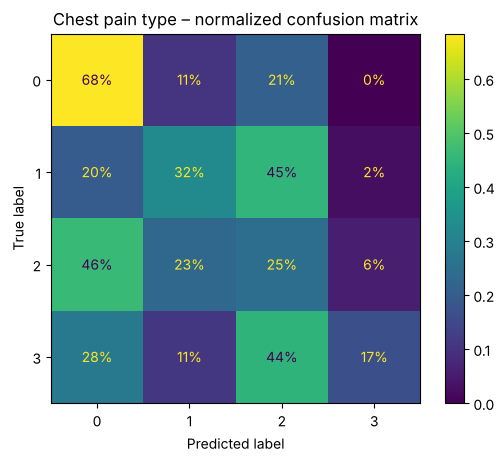

In [53]:
y_mc_pred = cross_val_predict(sgd_mc, X_mc_train, y_mc_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_mc_train, y_mc_pred, normalize="true", values_format=".0%")
plt.title("Chest pain type – normalized confusion matrix")
plt.show()

## Multilabel classification

Predict two labels at once: heart disease (`target`) and exercise-induced angina (`exang`).

In [54]:
X_ml = df_unique.drop(["target", "exang"], axis=1)
y_ml = df_unique[["target", "exang"]].values

X_ml_train, X_ml_test, y_ml_train, y_ml_test = train_test_split(
    X_ml, y_ml, test_size=0.2, random_state=42
)

knn_ml = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7))
knn_ml.fit(X_ml_train, y_ml_train)
print(knn_ml.predict(X_ml_test[:5]))

y_ml_pred = cross_val_predict(knn_ml, X_ml_train, y_ml_train, cv=3)
print("Macro F1:", f1_score(y_ml_train, y_ml_pred, average="macro"))

[[1 0]
 [1 0]
 [0 1]
 [0 0]
 [0 1]]
Macro F1: 0.7235392720306513
